## Use the image and text to image pipeline to edit images. 

In [ ]:
# Load this or install the requirements.txt
import sys
! pip install ipykernel
!{sys.executable} -m pip install torch diffusers transformers accelerate safetensors matplotlib Pillow ipython

In [1]:
import torch
from PIL import Image
import requests
from io import BytesIO
from diffusers import StableDiffusionImg2ImgPipeline
import numpy as np 
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
devise = 'cuda' if torch.cuda.is_available() else device
print(f"Using device: {devise}")

Using device: mps


In [ ]:
# Load pipeline
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(device)

print("pipeline loaded")

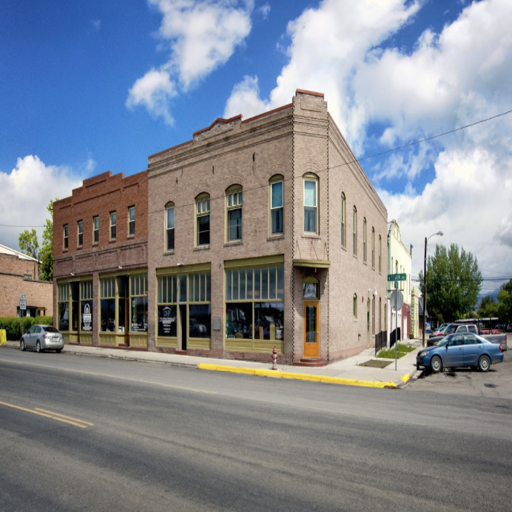

In [ ]:
# load the input image and display it
url = "https://images.squarespace-cdn.com/content/v1/5f0f175cf843e20f1d41be2e/1628693285665-N22RY9BIGMDXXEG15KAY/Borden+hotel+exterior+corner+Whitehall+MT.png"
response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image = init_image.resize((512, 512))
display(init_image)

In [ ]:
# The prompt of what we want changed. 

prompt = "a realistic european street with a single two-story building, " \
         "soft cinematic lighting, detailed textures, slightly cloudy sky, photorealistic, depth of field, clean perspective"

  0%|          | 0/37 [00:00<?, ?it/s]

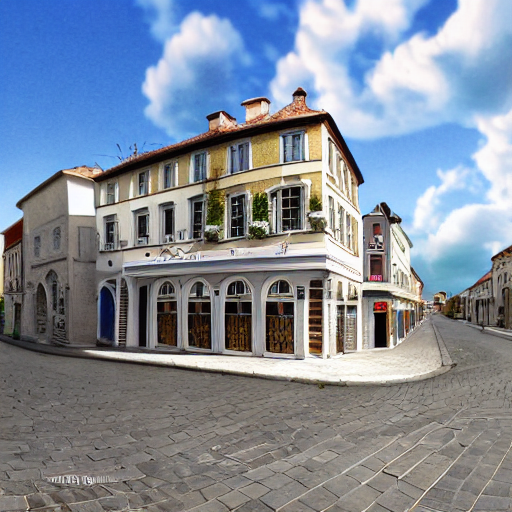

In [5]:
image = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=7.5
).images[0]
display(image)